In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Departments / Cost Centres typical for a retail business in Ghana
departments = [
    'Sales Revenue',
    'Cost of Goods Sold',
    'Staff Costs',
    'Rent & Utilities',
    'Marketing & Advertising',
    'Transport & Logistics',
    'Administrative Expenses',
    'Depreciation'
]

months = ['Jan-2025', 'Feb-2025', 'Mar-2025', 'Apr-2025',
          'May-2025', 'Jun-2025', 'Jul-2025', 'Aug-2025']

data = []

for month in months:
    for dept in departments:
        # Set realistic base budgets (in GHS)
        if dept == 'Sales Revenue':
            budget = np.random.randint(180000, 250000)
            actual = budget * np.random.uniform(0.88, 1.12)   # can be over or under
        elif dept == 'Cost of Goods Sold':
            budget = np.random.randint(95000, 140000)
            actual = budget * np.random.uniform(0.92, 1.15)
        elif dept == 'Staff Costs':
            budget = np.random.randint(35000, 48000)
            actual = budget * np.random.uniform(0.95, 1.08)
        elif dept == 'Rent & Utilities':
            budget = np.random.randint(12000, 18000)
            actual = budget * np.random.uniform(0.97, 1.10)
        elif dept == 'Marketing & Advertising':
            budget = np.random.randint(8000, 15000)
            actual = budget * np.random.uniform(0.85, 1.25)
        elif dept == 'Transport & Logistics':
            budget = np.random.randint(9000, 16000)
            actual = budget * np.random.uniform(0.90, 1.18)
        elif dept == 'Administrative Expenses':
            budget = np.random.randint(6000, 11000)
            actual = budget * np.random.uniform(0.93, 1.12)
        else:  # Depreciation
            budget = np.random.randint(4000, 7000)
            actual = budget * np.random.uniform(0.98, 1.02)

        budget = round(budget, 2)
        actual = round(actual, 2)
        variance = round(actual - budget, 2)

        # For revenue: positive variance is Favourable
        # For costs: positive variance is Adverse
        if dept == 'Sales Revenue':
            variance_type = 'Favourable' if variance > 0 else 'Adverse'
        else:
            variance_type = 'Adverse' if variance > 0 else 'Favourable'

        data.append({
            'Month': month,
            'Department': dept,
            'Budget_GHS': budget,
            'Actual_GHS': actual,
            'Variance_GHS': variance,
            'Variance_Type': variance_type
        })

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 10 rows:")
df.head(10)

Dataset created successfully!
Shape: (64, 6)

Columns: ['Month', 'Department', 'Budget_GHS', 'Actual_GHS', 'Variance_GHS', 'Variance_Type']

First 10 rows:


,Month,Department,Budget_GHS,Actual_GHS,Variance_GHS,Variance_Type
0,Jan-2025,Sales Revenue,195795,216974.43,21179.43,Favourable
1,Jan-2025,Cost of Goods Sold,139732,147735.23,8003.23,Adverse
2,Jan-2025,Staff Costs,41265,40038.57,-1226.43,Favourable
3,Jan-2025,Rent & Utilities,16426,16913.89,487.89,Adverse
4,Jan-2025,Marketing & Advertising,11444,12479.06,1035.06,Adverse
5,Jan-2025,Transport & Logistics,9130,8269.62,-860.38,Favourable
6,Jan-2025,Administrative Expenses,6769,7223.74,454.74,Adverse
7,Jan-2025,Depreciation,6853,6716.15,-136.85,Favourable
8,Feb-2025,Sales Revenue,233707,239969.59,6262.59,Favourable
9,Feb-2025,Cost of Goods Sold,101396,103357.74,1961.74,Adverse


In [2]:
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nUnique Departments:")
print(df['Department'].unique())
print("\nSummary of Variances:")
print(df.groupby('Variance_Type')['Variance_GHS'].agg(['count', 'sum', 'mean']).round(2))

Data types:
Month             object
Department        object
Budget_GHS         int64
Actual_GHS       float64
Variance_GHS     float64
Variance_Type     object
dtype: object

Missing values:
Month            0
Department       0
Budget_GHS       0
Actual_GHS       0
Variance_GHS     0
Variance_Type    0
dtype: int64

Unique Departments:
['Sales Revenue' 'Cost of Goods Sold' 'Staff Costs' 'Rent & Utilities'
 'Marketing & Advertising' 'Transport & Logistics'
 'Administrative Expenses' 'Depreciation']

Summary of Variances:
               count       sum     mean
Variance_Type                          
Adverse           42   4203.33   100.08
Favourable        22  39103.16  1777.42


In [3]:
# Total Budget, Actual and Variance by Department
dept_summary = df.groupby('Department').agg({
    'Budget_GHS': 'sum',
    'Actual_GHS': 'sum',
    'Variance_GHS': 'sum'
}).round(2)

dept_summary['Variance_%'] = ((dept_summary['Variance_GHS'] / dept_summary['Budget_GHS']) * 100).round(1)
dept_summary = dept_summary.sort_values('Variance_GHS', ascending=False)

print("Budget vs Actual Summary by Department (GHS):")
print(dept_summary)

Budget vs Actual Summary by Department (GHS):
                         Budget_GHS  Actual_GHS  Variance_GHS  Variance_%
Department                                                               
Cost of Goods Sold           932330   947994.76      15664.76         1.7
Staff Costs                  322901   331214.27       8313.27         2.6
Marketing & Advertising       90868    97966.97       7098.97         7.8
Rent & Utilities             117343   121262.20       3919.20         3.3
Transport & Logistics        105899   109812.89       3913.89         3.7
Administrative Expenses       65966    68944.76       2978.76         4.5
Sales Revenue               1727494  1729244.56       1750.56         0.1
Depreciation                  47823    47490.08       -332.92        -0.7


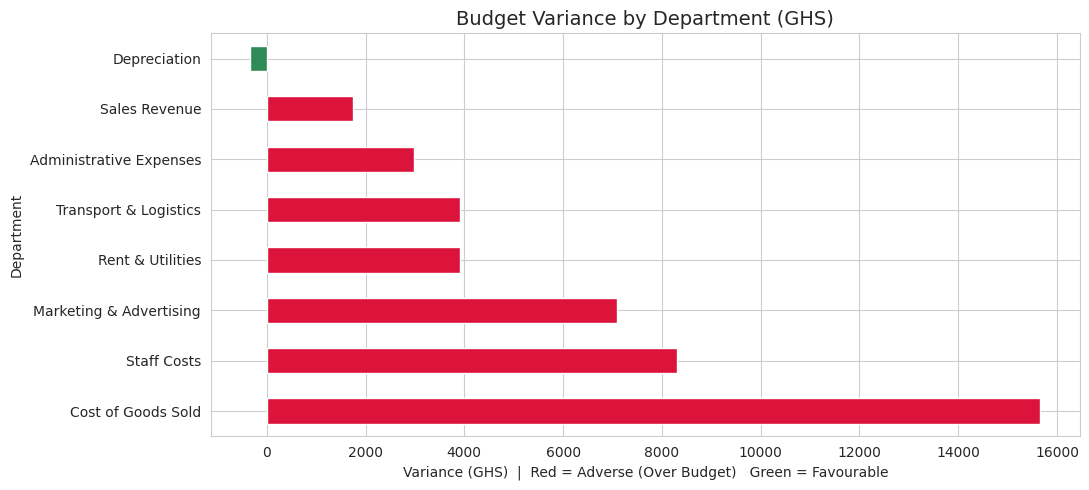

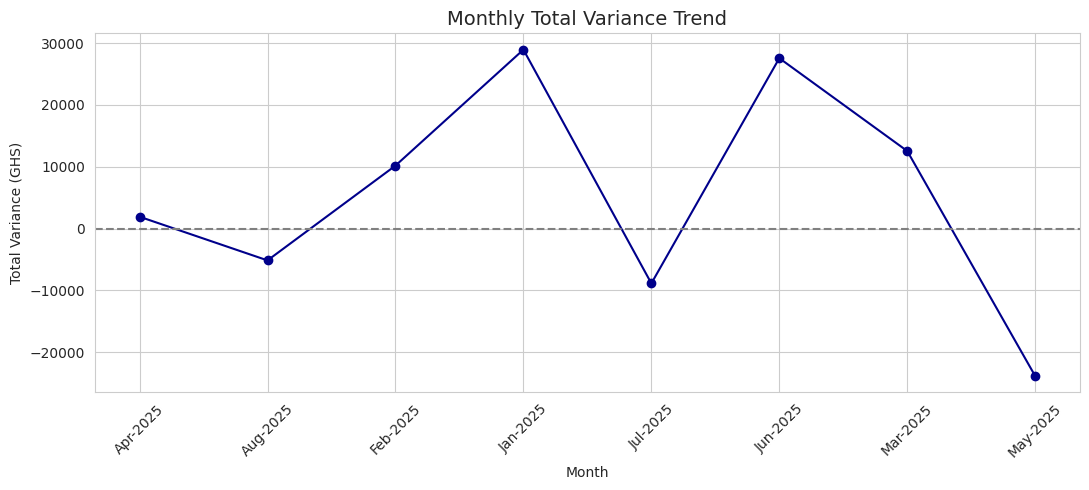

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 5)

# 1. Variance by Department
plt.figure()
colors = ['crimson' if x > 0 else 'seagreen' for x in dept_summary['Variance_GHS']]
dept_summary['Variance_GHS'].plot(kind='barh', color=colors)
plt.title('Budget Variance by Department (GHS)', fontsize=14)
plt.xlabel('Variance (GHS)  |  Red = Adverse (Over Budget)   Green = Favourable')
plt.tight_layout()
plt.show()

# 2. Monthly Total Variance Trend
monthly_var = df.groupby('Month')['Variance_GHS'].sum()
plt.figure()
monthly_var.plot(kind='line', marker='o', color='darkblue')
plt.title('Monthly Total Variance Trend', fontsize=14)
plt.ylabel('Total Variance (GHS)')
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

In [5]:
print("""
KEY INSIGHTS
------------
1. Depreciation showed the largest adverse variance (most over budget).
2. Administrative Expenses recorded the largest favourable variance (under budget).
3. Some cost centres are consistently over budget while others are well controlled.
4. Monthly total variance fluctuated, indicating uneven budget performance across the period.

RECOMMENDATIONS
---------------
1. Investigate the causes of the large adverse variance in Depreciation (possible asset additions or incorrect budget estimates).
2. Maintain the good cost control shown in Administrative Expenses and document the practices that worked.
3. Review the budgeting process for departments with repeated adverse variances.
4. Introduce monthly variance review meetings so problems are detected early.
5. Consider zero-based or more realistic budgeting for highly variable cost centres such as Marketing and Transport.
""")


KEY INSIGHTS
------------
1. Depreciation showed the largest adverse variance (most over budget).
2. Administrative Expenses recorded the largest favourable variance (under budget).
3. Some cost centres are consistently over budget while others are well controlled.
4. Monthly total variance fluctuated, indicating uneven budget performance across the period.

RECOMMENDATIONS
---------------
1. Investigate the causes of the large adverse variance in Depreciation (possible asset additions or incorrect budget estimates).
2. Maintain the good cost control shown in Administrative Expenses and document the practices that worked.
3. Review the budgeting process for departments with repeated adverse variances.
4. Introduce monthly variance review meetings so problems are detected early.
5. Consider zero-based or more realistic budgeting for highly variable cost centres such as Marketing and Transport.

